# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## Load the data

In [2]:
client_df = pd.read_csv('client_data.csv')
price_df = pd.read_csv('price_data.csv')

print(f"client_data shape: {client_df.shape}")
print(f"price_data shape:  {price_df.shape}")

client_df.head()


client_data shape: (14606, 26)
price_data shape:  (193002, 8)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [3]:
price_df.head()


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


## Data types


In [4]:
client_df.dtypes.sort_values()

churn                               int64
num_years_antig                     int64
cons_12m                            int64
cons_gas_12m                        int64
cons_last_month                     int64
nb_prod_act                         int64
forecast_cons_year                  int64
net_margin                        float64
margin_net_pow_ele                float64
margin_gross_pow_ele              float64
imp_cons                          float64
forecast_price_pow_off_peak       float64
forecast_price_energy_peak        float64
forecast_meter_rent_12m           float64
pow_max                           float64
forecast_discount_energy          float64
forecast_cons_12m                 float64
forecast_price_energy_off_peak    float64
has_gas                            object
date_renewal                       object
date_modif_prod                    object
date_end                           object
date_activ                         object
channel_sales                     

In [5]:
price_df.dtypes

id                     object
price_date             object
price_off_peak_var    float64
price_peak_var        float64
price_mid_peak_var    float64
price_off_peak_fix    float64
price_peak_fix        float64
price_mid_peak_fix    float64
dtype: object

In [6]:
# Convert date columns to proper datetime
client_date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in client_date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

price_df['price_date'] = pd.to_datetime(price_df['price_date'], errors='coerce')

# Keep id as string (identifier, not a quantity)
client_df['id'] = client_df['id'].astype(str)
price_df['id'] = price_df['id'].astype(str)

# Sanity check after conversion
client_df[client_date_cols].dtypes


date_activ         datetime64[ns]
date_end           datetime64[ns]
date_modif_prod    datetime64[ns]
date_renewal       datetime64[ns]
dtype: object

In [7]:
#confirm has_gas / churn are binary flags, and see what values they take
print("has_gas unique values:", client_df['has_gas'].unique())
print("churn unique values:  ", client_df['churn'].unique())

has_gas unique values: ['t' 'f']
churn unique values:   [1 0]


## Descriptive statistics

In [8]:
client_df.describe().T

,count,mean,min,25%,50%,75%,max,std
cons_12m,14606.0,159220.286252,0.0,5674.75,14115.5,40763.75,6207104.0,573465.264198
cons_gas_12m,14606.0,28092.375325,0.0,0.0,0.0,0.0,4154590.0,162973.059057
cons_last_month,14606.0,16090.269752,0.0,0.0,792.5,3383.0,771203.0,64364.196422
date_activ,14606,2011-01-28 07:54:18.879912448,2003-05-09 00:00:00,2010-01-15 00:00:00,2011-03-04 00:00:00,2012-04-19 00:00:00,2014-09-01 00:00:00,NaN
date_end,14606,2016-07-27 20:48:26.422018560,2016-01-28 00:00:00,2016-04-27 06:00:00,2016-08-01 00:00:00,2016-10-31 00:00:00,2017-06-13 00:00:00,NaN
date_modif_prod,14606,2013-01-02 12:29:10.951663872,2003-05-09 00:00:00,2010-08-12 00:00:00,2013-06-19 00:00:00,2015-06-16 00:00:00,2016-01-29 00:00:00,NaN
date_renewal,14606,2015-07-21 06:59:00.353279488,2013-06-26 00:00:00,2015-04-17 00:00:00,2015-07-27 00:00:00,2015-10-29 00:00:00,2016-01-28 00:00:00,NaN
forecast_cons_12m,14606.0,1868.61488,0.0,494.995,1112.875,2401.79,82902.83,2387.571531
forecast_cons_year,14606.0,1399.762906,0.0,0.0,314.0,1745.75,175375.0,3247.786255
forecast_discount_energy,14606.0,0.966726,0.0,0.0,0.0,0.0,30.0,5.108289


In [9]:
price_df.describe().T

,count,mean,min,25%,50%,75%,max,std
price_date,193002,2015-06-16 12:50:49.933161216,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-07-01 00:00:00,2015-10-01 00:00:00,2015-12-01 00:00:00,NaN
price_off_peak_var,193002.0,0.141027,0.0,0.125976,0.146033,0.151635,0.2807,0.025032
price_peak_var,193002.0,0.05463,0.0,0.0,0.085483,0.101673,0.229788,0.049924
price_mid_peak_var,193002.0,0.030496,0.0,0.0,0.0,0.072558,0.114102,0.036298
price_off_peak_fix,193002.0,43.334477,0.0,40.728885,44.26693,44.44471,59.44471,5.410297
price_peak_fix,193002.0,10.622875,0.0,0.0,0.0,24.339581,36.490692,12.841895
price_mid_peak_fix,193002.0,6.409984,0.0,0.0,0.0,16.226389,17.458221,7.773592


In [10]:
# Number of unique values per column
uniques = client_df.nunique().sort_values()
uniques


churn                                 2
has_gas                               2
origin_up                             6
channel_sales                         8
nb_prod_act                          10
forecast_discount_energy             12
num_years_antig                      13
forecast_price_pow_off_peak          41
forecast_price_energy_peak          329
date_end                            368
date_renewal                        386
forecast_price_energy_off_peak      516
pow_max                             698
date_activ                         1796
cons_gas_12m                       2112
date_modif_prod                    2129
margin_net_pow_ele                 2391
margin_gross_pow_ele               2391
forecast_meter_rent_12m            3528
forecast_cons_year                 4218
cons_last_month                    4751
imp_cons                           7752
cons_12m                          11065
net_margin                        11965
forecast_cons_12m                 13993


In [11]:
price_df.nunique().sort_values()

price_date               12
price_mid_peak_fix       28
price_peak_fix           31
price_off_peak_fix       66
price_mid_peak_var      711
price_peak_var         1189
price_off_peak_var     1853
id                    16096
dtype: int64

In [12]:
# Missing values
missing_client = client_df.isna().mean().sort_values(ascending=False) * 100
missing_client = missing_client[missing_client > 0]
print("Columns with missing values (client_data, % missing):")
missing_client

Columns with missing values (client_data, % missing):


Series([], dtype: float64)

In [13]:
missing_price = price_df.isna().mean().sort_values(ascending=False) * 100
missing_price = missing_price[missing_price > 0]
print("Columns with missing values (price_data, % missing):")
missing_price

Columns with missing values (price_data, % missing):


Series([], dtype: float64)

In [14]:
# Churn rate 
churn_rate = client_df['churn'].mean()
print(f"Overall churn rate: {churn_rate:.2%}")
client_df['churn'].value_counts()

Overall churn rate: 9.72%


churn
0    13187
1     1419
Name: count, dtype: int64

## Visualizations

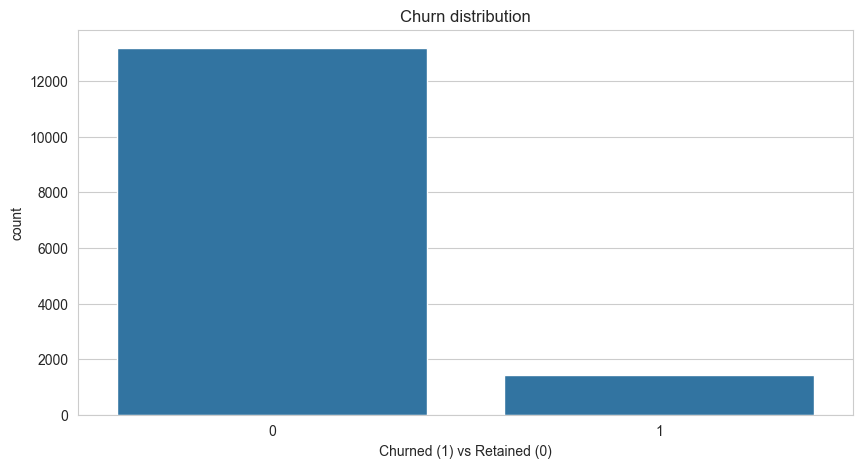

In [15]:
# Churn distribution 
ax = sns.countplot(data=client_df, x='churn')
ax.set_title('Churn distribution')
ax.set_xlabel('Churned (1) vs Retained (0)')
plt.show()


Skipping (not in this file): {'activity_new'}


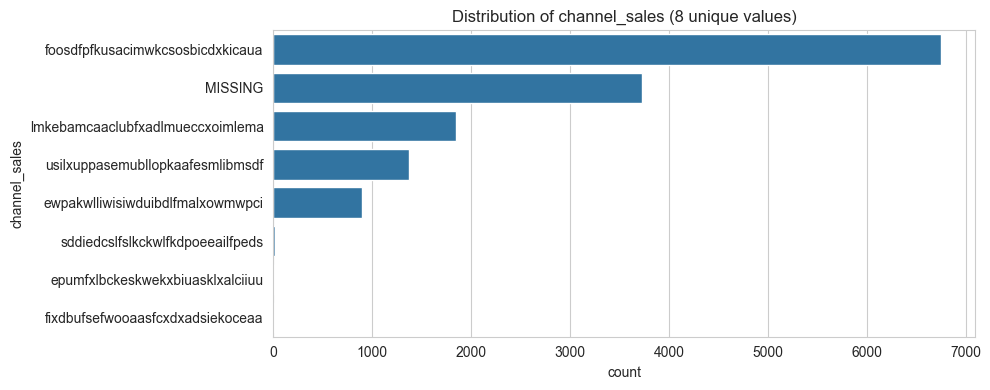

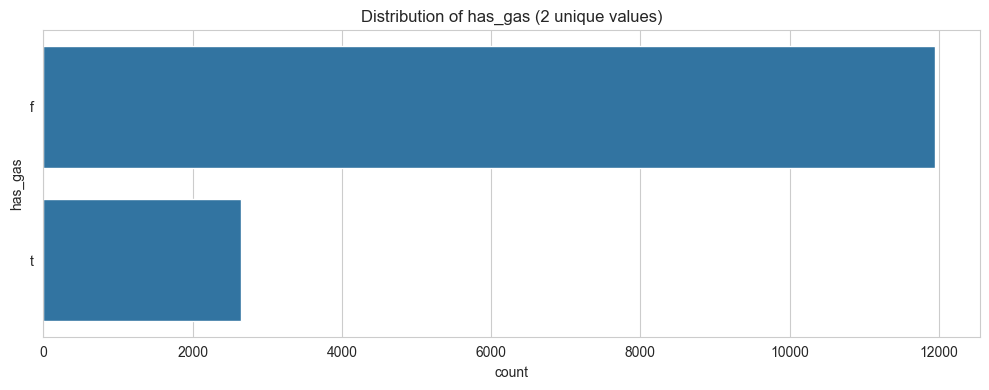

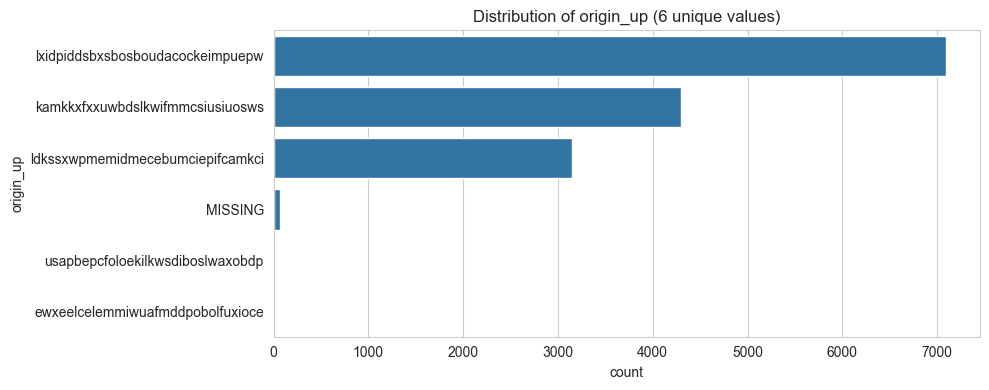

In [19]:
# Categorical columns with low cardinality
candidate_categorical_cols = ['channel_sales', 'has_gas', 'origin_up', 'activity_new']
categorical_cols = [c for c in candidate_categorical_cols if c in client_df.columns]

skipped = set(candidate_categorical_cols) - set(categorical_cols)
if skipped:
    print(f"Skipping (not in this file): {skipped}")

for col in categorical_cols:
    n_unique = client_df[col].nunique()
    plt.figure(figsize=(10, 4))
    if n_unique <= 15:
        order = client_df[col].value_counts().index
        sns.countplot(data=client_df, y=col, order=order)
        plt.title(f'Distribution of {col} ({n_unique} unique values)')
    else:
        top_vals = client_df[col].value_counts().nlargest(15)
        sns.barplot(x=top_vals.values, y=top_vals.index)
        plt.title(f'Top 15 most common values: {col} ({n_unique} unique total)')
    plt.tight_layout()
    plt.show()

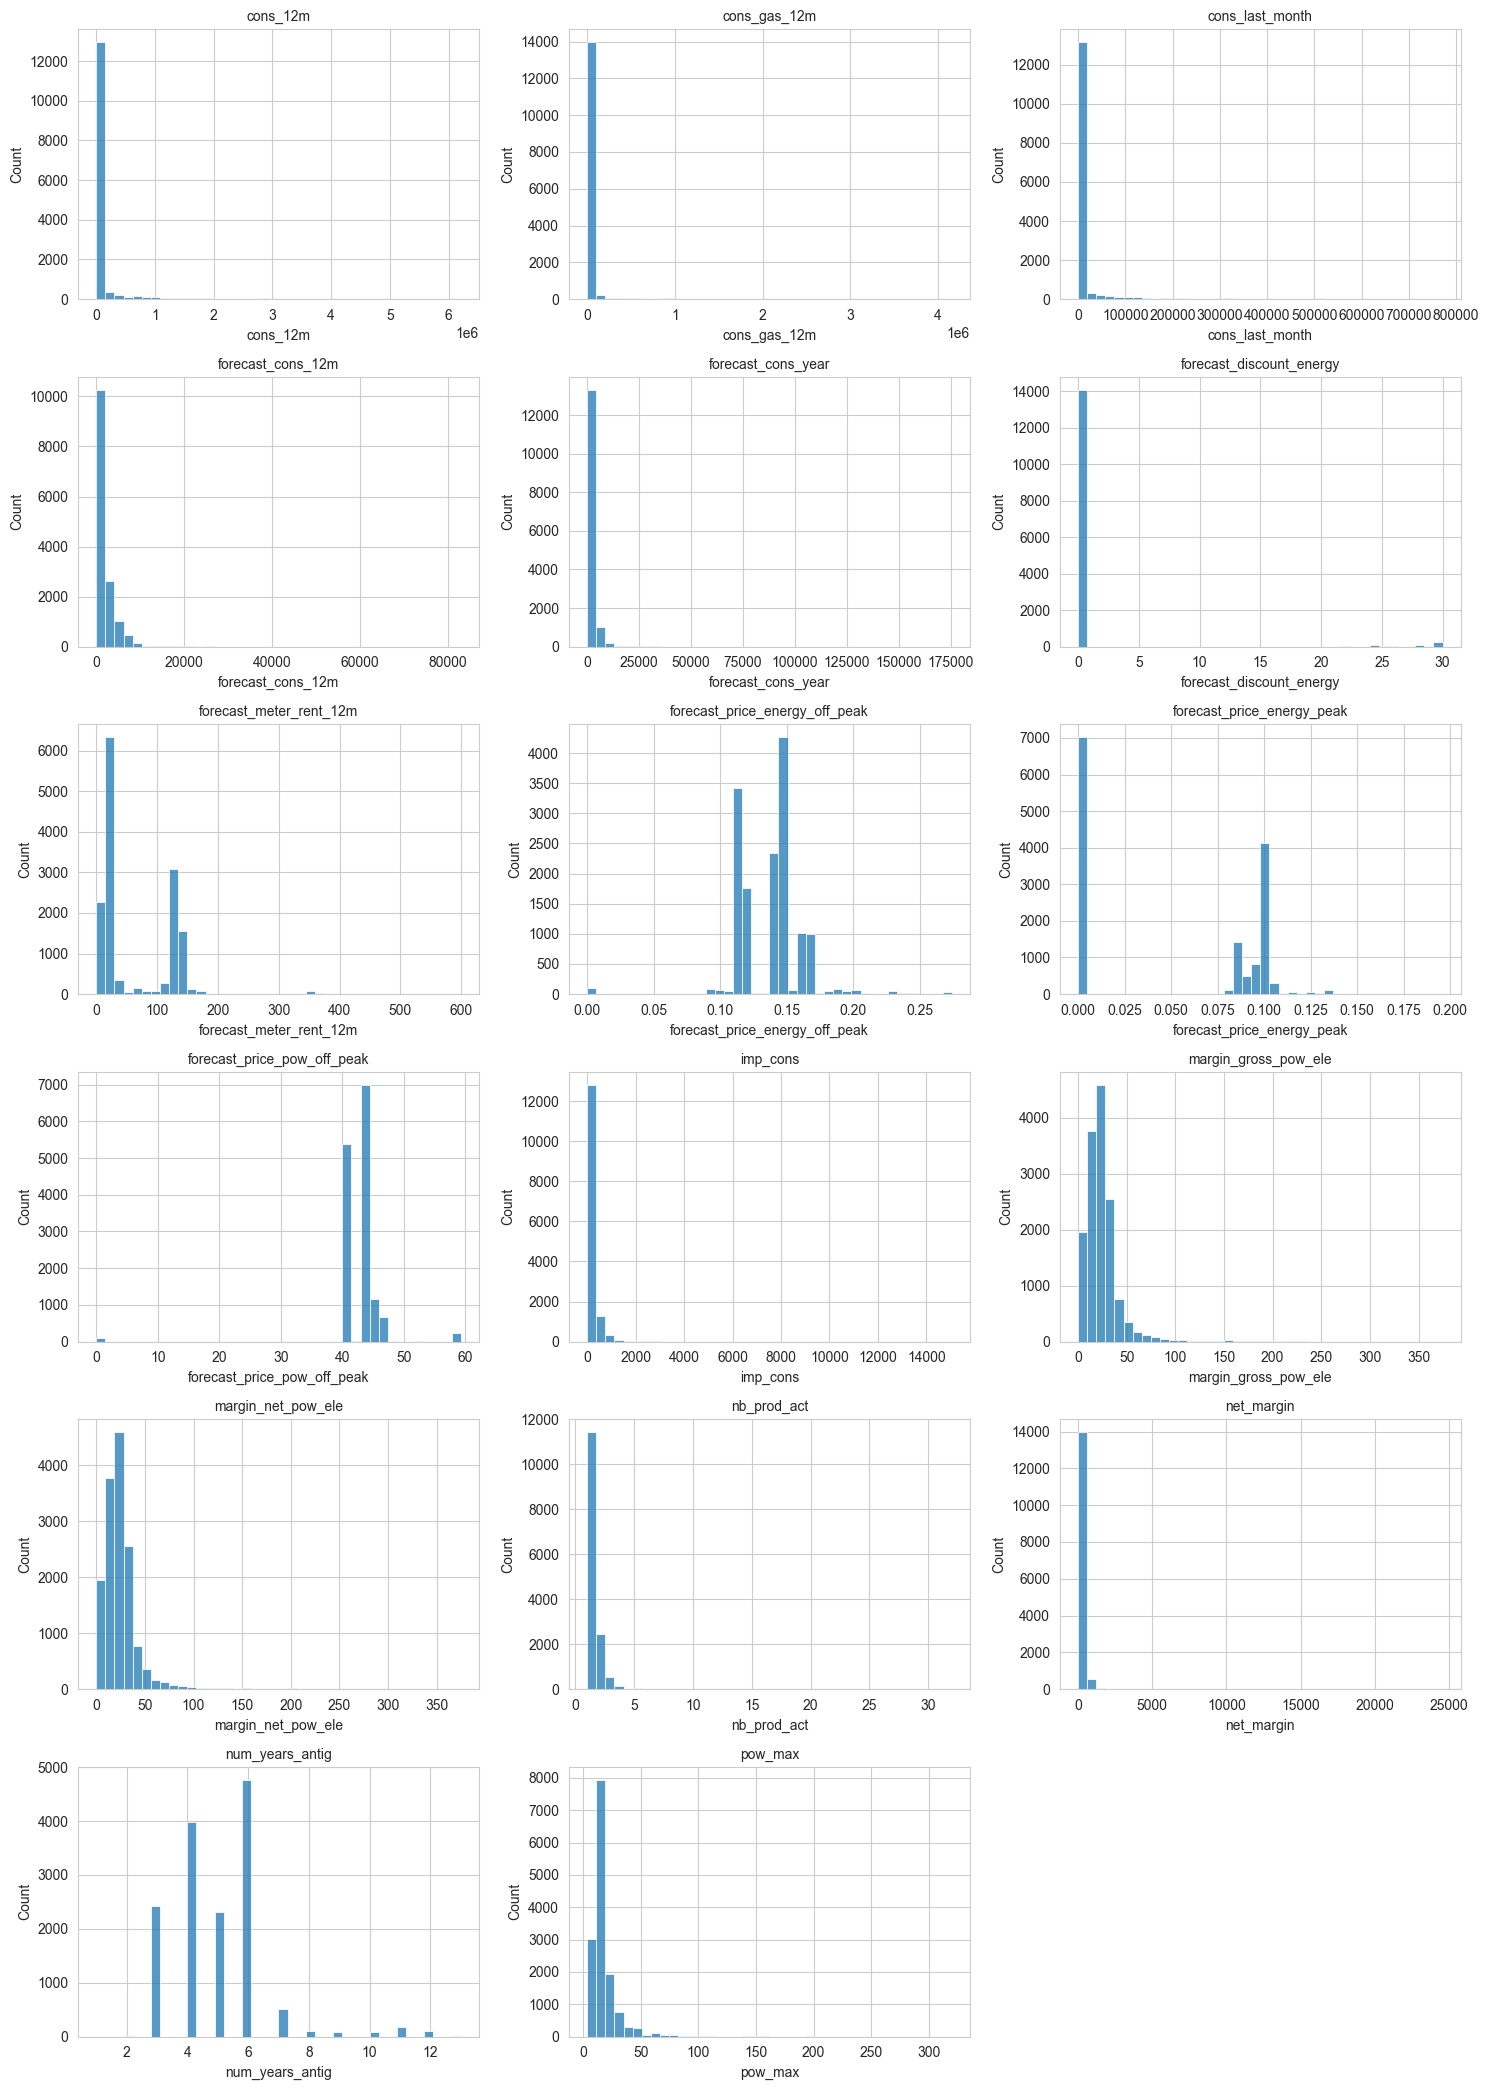

In [17]:
# Numeric columns — histograms 
numeric_cols = client_df.select_dtypes(include=[np.number]).columns.tolist()
# churn is binary, already covered above
numeric_cols = [c for c in numeric_cols if c != 'churn']

n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(client_df[col].dropna(), bins=40, ax=axes[i])
    axes[i].set_title(col, fontsize=10)

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


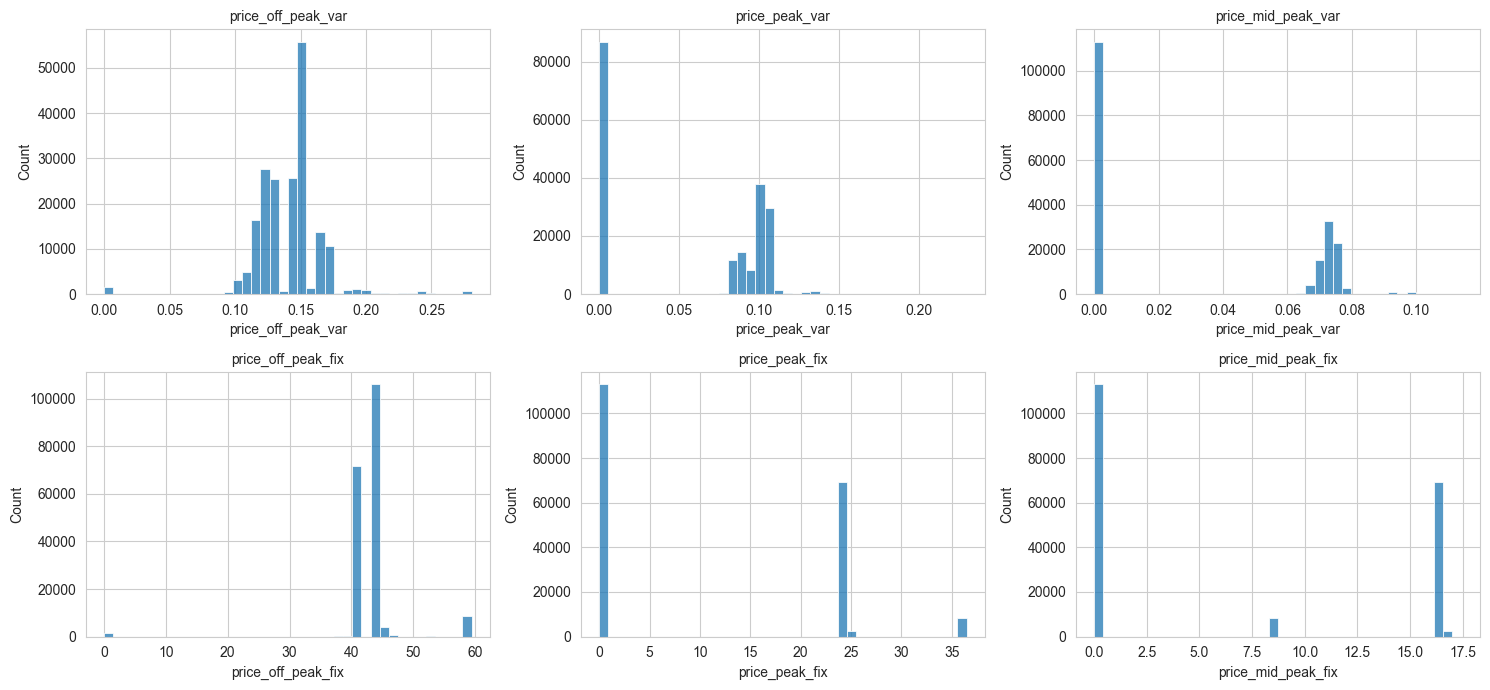

In [20]:
# price_data.csv price columns
price_cols = [c for c in price_df.columns if c.startswith('price_') and c != 'price_date']

n_cols = 3
n_rows = -(-len(price_cols) // n_cols)  # ceiling division, auto-sizes the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(price_cols):
    sns.histplot(price_df[col].dropna(), bins=40, ax=axes[i])
    axes[i].set_title(col, fontsize=10)

for j in range(len(price_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


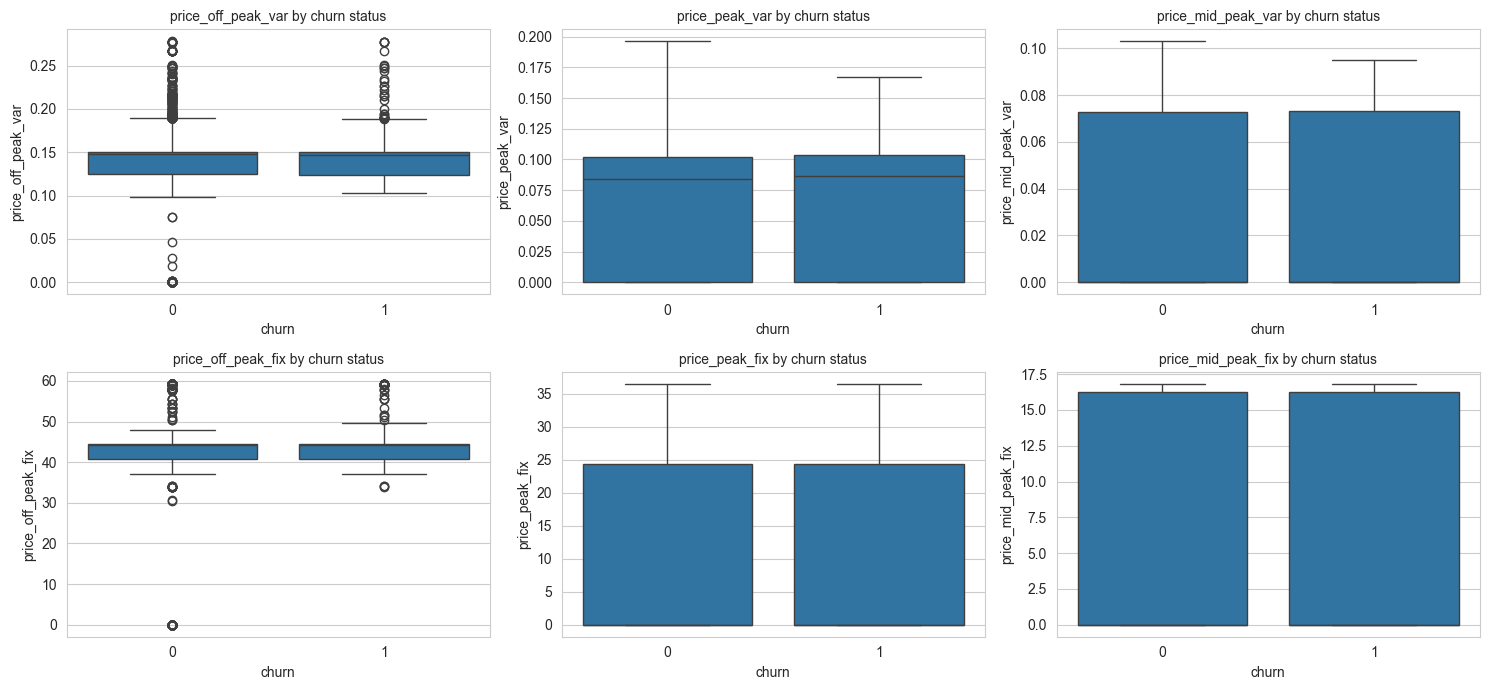

In [21]:
# Quick first cut at the actual hypothesis: does churn correlate with average price paid?

avg_price_per_customer = (
    price_df.groupby('id')[price_cols].mean().reset_index()
)

merged = client_df[['id', 'churn']].merge(avg_price_per_customer, on='id', how='left')

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(price_cols):
    sns.boxplot(data=merged, x='churn', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by churn status', fontsize=10)
plt.tight_layout()
plt.show()


## Notes / next steps

- Flag any columns above that turned out to be constant (`nunique() == 1`) — drop
  them, they add nothing to a model.
- Flag columns with high missingness — decide impute vs. drop per column.
- The boxplots above are a first visual gut-check only; the real test of the
  price-sensitivity hypothesis needs feature engineering (e.g. price change
  pre/post churn window, price relative to market average) and a proper model —
  that's Steps 3–4.
